In [1]:
using Random
using LinearAlgebra
using Statistics
using Distributions 
using Optim 
using Combinatorics
using MLDataUtils
using ForwardDiff
using Plots

# Dados 

In [2]:
function simulate_iv(N; β0, ρ, φ, π, m)
    z1 = randn(N)
    v  = randn(N)
    θ2 = randn(N)
    θ1 = abs.(z1) .* randn(N)       # N(0, z1_t^2)

    ε = ρ .* v .+ sqrt(1 - ρ^2) .* (φ .* θ1 .+ sqrt(1 - φ^2) .* θ2)

    X = π .* z1 .+ v
    y = β0 .* X .+ ε

    # Z = [1, z1, z1^2, z1^3, z1^4, z1*D1, ...]
    Z = ones(N, m)
    npowers = 4
    for j in 0:npowers
        Z[:, j+1] = z1 .^ j
    end
    for k in 6:m
        Dk = rand(N) .< 0.5                      # Bool ~ Bernoulli(0.5)
        Z[:, k] = z1 .* Float64.(Dk)
    end

    return reshape(y, :, 1) , reshape(X, :, 1), Z
end

# exemplo de uso (sem seed):
N = 400

y, X, Z = simulate_iv(N; β0= 10, ρ=0.3, φ=0.5, π=sqrt(8), m=30)

([40.743874438630684; -22.500311265658063; … ; -39.414115485717424; -16.112814605825534;;], [3.9311646684827415; -2.263473103188985; … ; -3.930736134500375; -1.8584315641034914;;], [1.0 1.2517036136020967 … 1.2517036136020967 0.0; 1.0 -0.8701287071153873 … -0.0 -0.0; … ; 1.0 -0.9511119972201201 … -0.0 -0.9511119972201201; 1.0 -0.9772750462748526 … -0.0 -0.9772750462748526])

# Estimação

In [3]:
function obj_liml_pure(beta::Vector, y::Matrix, X::Matrix, Z::Matrix)     # Q(b) = LIML(b)
    
    u = y - X * beta 
    u_hat = Z * (Z \ u) 

    numerator_matrix = u_hat' * u_hat
    denominator_matrix = u' * u                  
    
    return (numerator_matrix[1] / denominator_matrix[1])
end

function Q(beta::Vector, y::Matrix, X::Matrix, Z::Matrix , beta_liml::Vector ,  id::Integer)     

    if id == 3                                

        cue_to_h = b -> obj_liml_pure(b, y, X, Z)
        D2Q = ForwardDiff.hessian(cue_to_h, beta_liml)                                                # quadratifica a função objetivo no caso id 4
        obj = cue_to_h(beta_liml) +  (1/2)*(beta - beta_liml)'*D2Q*(beta - beta_liml)
        return obj  
        
    else               
        
        return obj_liml_pure(beta , y , X , Z)


    end     
end

Q (generic function with 1 method)

In [4]:
function LIML(y::AbstractMatrix, X::AbstractMatrix, Z::AbstractMatrix)    # encontra o estimador de LIML
    Y = hcat(y, X)
    YtZ = Y' * Z
    temp = Z\Y
    A = YtZ * temp
    B = Y' * Y
    vals, vecs = eigen(A, B)
    min_idx = argmin(vals)
    v = vecs[:, min_idx]
    return -v[2:end] ./ v[1]
end

function TSLS(y::AbstractMatrix, X::AbstractMatrix, Z::AbstractMatrix)    # encontra o estimador de TSLS
    X_hat = Z * (Z \ X)
    beta_2sls = X_hat \ y
    return beta_2sls
end

function Q_max_min(y::AbstractMatrix, X::AbstractMatrix, Z::AbstractMatrix)
    Y = hcat(y, X)
    YtZ = Y' * Z
    temp = Z\Y
    A = YtZ * temp
    B = Y' * Y
    vals, vecs = eigen(A, B)
    return  maximum(vals) - minimum(vals)           # dá a imagem da função objetivo
end

Q_max_min (generic function with 1 method)

In [ ]:
function g(x)

    return sqrt(1 + x^2) - 1

end     

function r(  beta::Vector ,  beta_liml::Vector , id::Integer  )

    L2 = norm(beta , 2)^2 / norm( beta_liml , 2)^2
    betasq = beta.^2

    if         id == 0  
        
        penalty = 0

    elseif     id == 1
       
        penalty = L2
     
    elseif     id == 2    
  
        penalty = 2 * (L2) / (1 + L2) 

    elseif     id == 3    
       
        penalty = L2 


    elseif id == 4
        
        penalty =   (  log(1 + L2)/( 1 + log(1 + L2)) )/(  log(2)/( 1 + log(2)) )

    elseif id ==5 

        terms = [      (  beta[j]^2/ beta_liml[j]^2  )/( 1 +  beta[j]^2/ beta_liml[j]^2  )  for j in 1:length(beta)     ]

        penalty =  2*mean(   terms   )   

    elseif id == 6
        
        W = [ 1/abs(beta_liml[j]) for j in 1:length(beta_liml)]

        w = W / sum(W)

        terms = [     beta[j]^2 /( 1 +  beta[j]^2  )  for j in 1:length(beta)    ]        # no caso univariado, = penalidade 2 sem dividir por h no caso 

        penalty = 2 * sum( [w[j] * terms[j]  for j in 1:length(beta) ]  )

    elseif id == 7

        W = [ 1/g(beta_liml[j] )for j in 1:length(beta_liml)]

        w = W / sum(W)

        terms = [     g(beta[j]) /( 1 +  g(beta[j])  )  for j in 1:length(beta)    ]

        penalty = 2 * sum( [w[j] * terms[j]  for j in 1:length(beta) ]  )


    else
         
        error("id fora do domínio")

    end 

    return penalty 
end    

r (generic function with 1 method)

In [6]:
function guess(betaA, betaB, betaC)
    k = length(betaA)

    S = promote_type(eltype(betaA), eltype(betaB), eltype(betaC))
    combos = Vector{Vector{S}}()

    # enumeração em base 3: 0->A, 1->B, 2->C
    for s in 0:(3^k - 1)
        v = Vector{S}(undef, k)
        N = s
        @inbounds for i in 1:k
            r = N % 3
            N ÷= 3
            v[i] = r == 0 ? S(betaA[i]) : (r == 1 ? S(betaB[i]) : S(betaC[i]))
        end
        push!(combos, v)
    end

    push!(combos, fill(zero(S), k))  # único vetor de zeros
    return combos
end

# guess([1,2], [3,4], [5,6])  para visualizar

function optimizador(y::Matrix, X::Matrix, Z::Matrix, lambda::Real, id::Integer, beta_true::Vector)

    beta_liml = LIML( y, X , Z )  
    beta_2sls = TSLS(y,X,Z)              

    if id == 0

        return beta_liml 

    else 

        func_to_minimize = b -> Q(b, y, X, Z , beta_liml, id) + lambda * r(b, beta_liml, id)


        combinacoes = guess(  beta_true  , beta_liml , beta_2sls )

        best_solution = nothing
        min_objective_value = Inf

        for (i, start_point) in enumerate(combinacoes)

            results = optimize(func_to_minimize, start_point, LBFGS())

            if Optim.converged(results)
                current_min = Optim.minimum(results)
                    if current_min < min_objective_value
                        # Atualiza a melhor solução
                        min_objective_value = current_min
                        best_solution = Optim.minimizer(results)
                    end
            end
        end

        return best_solution
    end     

end

optimizador (generic function with 1 method)

# Simulação: Instrumentos Fortes

In [7]:
n = 400

p = 1
m = 50

beta_true = [10]


CP = 16

π = sqrt( CP / n  )        # regra de bolso para o CP   quando sigma_v = 1 (nosso caso)
ρ = 0.3
φ = 0.5

A = 200

num_penalties = 6

# simulação 

Random.seed!(123)
results = zeros( p , num_penalties + 1 , A )

for a in 1:A 
 
    y , X , Z =  simulate_iv(n; β0 = beta_true, ρ, φ, π, m)

    for id in 0:num_penalties , 
        
        λ = Q_max_min(y, X, Z)/15
        
        results[ : , id + 1 , a  ]  = optimizador(y , X , Z, λ, id, beta_true)

        print("\r... completou a replicação de Monte Carlo $a/$A")
        flush(stdout)
    
    end     
end 

... completou a replicação de Monte Carlo 200/200

In [8]:
desvios_true = zeros( num_penalties + 1 , A )
desvios_mean = zeros(  num_penalties + 1 , A )

for a in 1:A , id in 0:num_penalties

    desvios_true[ id + 1 , a ] = results[ 1 , id + 1 , a  ] - beta_true[1]
    desvios_mean[ id + 1 , a ] = results[ 1 , id + 1 , a  ] - mean(  results[ 1 , id + 1 , :  ] )

end    


erros_medios = zeros(num_penalties + 1)
erros_medianos = zeros(num_penalties + 1)

sd = zeros(num_penalties + 1)
idr = zeros(num_penalties + 1)
iqr = zeros(num_penalties + 1)

mse = zeros(num_penalties + 1)
medse = zeros(num_penalties + 1)


for id in 0:num_penalties
  
   erros_medios[id + 1] =  mean( desvios_true[ id + 1 , : ] )  

   erros_medianos[id + 1] =  quantile(  desvios_true[ id + 1 , : ] , 0.5 ) 

   
   sd[id + 1] =  mean(abs2, desvios_mean[id+1, :])   ^ (1/2)

   idr[id + 1] =  quantile(  results[ 1 , id + 1 , :  ] , 0.9 ) - quantile(  results[ 1 , id + 1 , :  ] , 0.1 )
   iqr[id + 1] =  quantile(  results[ 1 , id + 1 , :  ] , 0.99 ) - quantile(  results[ 1 , id + 1 , :  ] , 0.01 )


   mse[id + 1] = mean( abs2, desvios_true[ id + 1 , : ] )
   medse[id + 1] = median(  desvios_true[ id + 1 , : ] .^2 )
   
end     


println("--- Análise Detalhada de Métricas por Penalidade ---")

for id in 0:num_penalties
    println("\n" * "="^40)
    println("Resultados para Penalidade $id")
    println("="^40)
    
    println("\n--- Métricas Escalares de Resumo ---")
    println("Erro Mediano:   ", erros_medianos[id + 1])
    println("Desvio-Padrão:  ", sd[id + 1])
    println("IDR (Q90-Q10):  ", idr[id + 1])
    println("IQR (Q99-Q01):  ", iqr[id + 1])
    println("MSE:            ", mse[id + 1])
    println("Median SE:      ", medse[id + 1])
end

--- Análise Detalhada de Métricas por Penalidade ---

Resultados para Penalidade 0

--- Métricas Escalares de Resumo ---
Erro Mediano:   -0.4920055701543822
Desvio-Padrão:  22.55851235090983
IDR (Q90-Q10):  6.968033623543437
IQR (Q99-Q01):  47.55852104543301
MSE:            517.6329717359049
Median SE:      1.2521378077580438

Resultados para Penalidade 1

--- Métricas Escalares de Resumo ---
Erro Mediano:   -0.7109071604960588
Desvio-Padrão:  5.454885815228432
IDR (Q90-Q10):  11.348417524991088
IQR (Q99-Q01):  20.510901859242594
MSE:            37.98581560673508
Median SE:      1.4000688196373205

Resultados para Penalidade 2

--- Métricas Escalares de Resumo ---
Erro Mediano:   -0.6963719969572022
Desvio-Padrão:  5.158968209185404
IDR (Q90-Q10):  11.320584385304446
IQR (Q99-Q01):  18.676472770341128
MSE:            34.223677382702654
Median SE:      1.3140491844781952

Resultados para Penalidade 3

--- Métricas Escalares de Resumo ---
Erro Mediano:   -0.6122706878412361
Desvio-Padrão

# Instrumentos fracos

In [9]:
n = 400

p = 1
m = 50

beta_true = [10]


CP = 8

π = sqrt( CP / n  )        # regra de bolso para o CP   quando sigma_v = 1 (nosso caso)
ρ = 0.3
φ = 0.5

A = 200

num_penalties = 6

# simulação 

Random.seed!(123)


results = zeros( p , num_penalties + 1 , A )


for a in 1:A 
 
    y , X , Z =  simulate_iv(n; β0 = beta_true, ρ, φ, π, m)

    for id in 0:num_penalties , 
        
        λ = Q_max_min(y, X, Z)/15
        
        results[ : , id + 1 , a  ]  = optimizador(y , X , Z, λ, id, beta_true)

        print("\r... completou a replicação de Monte Carlo $a/$A")
        flush(stdout)
    
    end     
end 

... completou a replicação de Monte Carlo 200/200

In [10]:
desvios_true = zeros( num_penalties + 1 , A )
desvios_mean = zeros(  num_penalties + 1 , A )

for a in 1:A , id in 0:num_penalties

    desvios_true[ id + 1 , a ] = results[ 1 , id + 1 , a  ] - beta_true[1]
    desvios_mean[ id + 1 , a ] = results[ 1 , id + 1 , a  ] - mean(  results[ 1 , id + 1 , :  ] )

end    


erros_medios = zeros(num_penalties + 1)
erros_medianos = zeros(num_penalties + 1)

sd = zeros(num_penalties + 1)
idr = zeros(num_penalties + 1)
iqr = zeros(num_penalties + 1)

mse = zeros(num_penalties + 1)
medse = zeros(num_penalties + 1)


for id in 0:num_penalties
  
   erros_medios[id + 1] =  mean( desvios_true[ id + 1 , : ] )  

   erros_medianos[id + 1] =  quantile(  desvios_true[ id + 1 , : ] , 0.5 ) 

   
   sd[id + 1] =  mean(abs2, desvios_mean[id+1, :])   ^ (1/2)

   idr[id + 1] =  quantile(  results[ 1 , id + 1 , :  ] , 0.9 ) - quantile(  results[ 1 , id + 1 , :  ] , 0.1 )
   iqr[id + 1] =  quantile(  results[ 1 , id + 1 , :  ] , 0.99 ) - quantile(  results[ 1 , id + 1 , :  ] , 0.01 )


   mse[id + 1] = mean( abs2, desvios_true[ id + 1 , : ] )
   medse[id + 1] = median(  desvios_true[ id + 1 , : ] .^2 )
   
end     


println("--- Análise Detalhada de Métricas por Penalidade ---")

for id in 0:num_penalties
    println("\n" * "="^40)
    println("Resultados para Penalidade $id")
    println("="^40)
    
    println("\n--- Métricas Escalares de Resumo ---")
    println("Erro Mediano:   ", erros_medianos[id + 1])
    println("Desvio-Padrão:  ", sd[id + 1])
    println("IDR (Q90-Q10):  ", idr[id + 1])
    println("IQR (Q99-Q01):  ", iqr[id + 1])
    println("MSE:            ", mse[id + 1])
    println("Median SE:      ", medse[id + 1])
end

--- Análise Detalhada de Métricas por Penalidade ---

Resultados para Penalidade 0

--- Métricas Escalares de Resumo ---
Erro Mediano:   -0.4929811421883521
Desvio-Padrão:  28.383112315630502
IDR (Q90-Q10):  12.209665335045765
IQR (Q99-Q01):  85.17801591201021
MSE:            805.7379953990535
Median SE:      4.140471423219619

Resultados para Penalidade 1

--- Métricas Escalares de Resumo ---
Erro Mediano:   -1.1281644114568943
Desvio-Padrão:  6.536396004084018
IDR (Q90-Q10):  16.146409660497987
IQR (Q99-Q01):  22.665920099491164
MSE:            59.03813383779318
Median SE:      4.593164482210985

Resultados para Penalidade 2

--- Métricas Escalares de Resumo ---
Erro Mediano:   -1.0971890045383939
Desvio-Padrão:  6.141303216981613
IDR (Q90-Q10):  14.821230953893261
IQR (Q99-Q01):  20.55131096669422
MSE:            52.701266239575446
Median SE:      4.489980467250913

Resultados para Penalidade 3

--- Métricas Escalares de Resumo ---
Erro Mediano:   -0.8436889167703594
Desvio-Padrão: 

# Otimização?

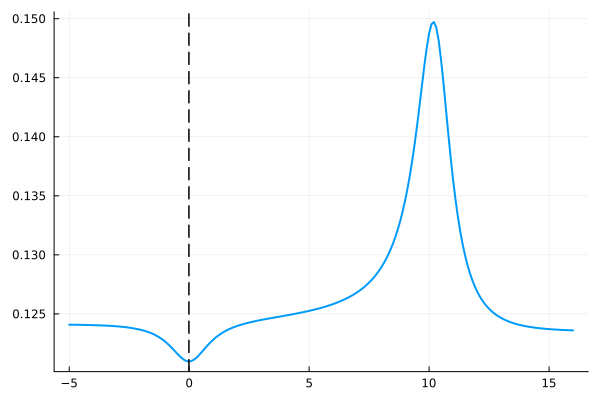

In [44]:
id = 6

y , X , Z =  simulate_iv(n; β0 = beta_true, ρ, φ, π, m)

λ = Q_max_min(y, X, Z) /15

solution = optimizador(y , X , Z , λ , id , [10] )



obj = b -> Q(b, y, X, Z , LIML(y,X,Z), id) + λ * r(b, LIML(y,X,Z), id)


x_grid = -5:(0.1):16
y_grid = obj.([ [i] for i in  x_grid])


plot(x_grid, y_grid , label="" ,  linewidth=2)
vline!([solution], label="", color=:black, linestyle=:dash, linewidth=1.5)